# EICC GRPO Training Notebook (Theme #3.1 World Modeling)

Colab / HF-Space-ready notebook. **Just run the cells top-to-bottom** — the default flow trains and evaluates against the **VM environment (Mode 3)**, which is the harder, more realistic lane. The Mock environment (Mode 2) lane is provided as commented-out alternatives in the same cells in case you want to compare.

## Two lanes, one trained checkpoint

- **VM environment (Mode 3) — default lane**: same `/reset`+`/step` API, routed to a **live container cluster** running on `127.0.0.1` via `python -m sandbox.launch_no_docker`. This is what the default cells below run.
- **Mock environment (Mode 2) — optional lane**: deterministic simulated backend, fully in-process. Available as commented lines you can uncomment if you want.

Both lanes evaluate the **same** trained adapter from Step 5, so the gap between them is a direct sim→VM transfer measurement.

## Run order (default = VM env)

| Step | What it does |
|---|---|
| 1 | Clone repo |
| 2 | Install training deps (Unsloth + TRL + peft + bitsandbytes + fastapi/uvicorn) |
| 3 | Dry-run sanity check |
| ⚠️ | **Start `python -m sandbox.launch_no_docker` in a SEPARATE terminal** (cell right above Step 4) |
| 4 | (Optional) Mock-env baseline — the default sandbox baseline is produced by Step 6 below |
| 5 | GRPO training (~1 hour quick profile) — produces `artifacts/train/trained_adapter/` |
| 6 | Compare baseline vs trained on the **VM env** (default; writes both reports in one call) |
| 7 | Inspect reports + `policy_used` provenance |
| 8 | Display 3 mentor curves (easy / medium / hard) |

## Where outputs go

- VM env (default) → `artifacts/eval_sandbox/` (baseline_report.json, trained_report.json, reward_curve_{easy,medium,hard}.png)
- Mock env (optional) → `artifacts/eval_simple/` (same filenames)
- Training → `artifacts/train/trained_adapter/` + `artifacts/train/reward_history.json`

For final submission, copy curated files into `results/sandbox/`, `results/simple/`, and `results/training/` (those folders are tracked in git).


In [1]:
# Step 1: Clone your repo
!git clone https://github.com/anujkamaljain/OpenEnv-Customer-Support.git
%cd OpenEnv-Customer-Support

Cloning into 'OpenEnv-Customer-Support'...
remote: Enumerating objects: 432, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 432 (delta 37), reused 72 (delta 25), pack-reused 329 (from 1)
Receiving objects: 100% (432/432), 571.79 KiB | 27.23 MiB/s, done.
Resolving deltas: 100% (188/188), done.
/data/OpenEnv-Customer-Support


/home/user/miniconda/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# Step 2: Install training dependencies (clean path)
# If Colab asks for runtime restart, restart and rerun from Step 1.
%pip install -q -U pip setuptools wheel jedi
%pip install -q -U "pydantic>=2.12,<3" "click<8.2"
%pip install -q -U "trl==0.15.2" "transformers==4.51.3" datasets peft bitsandbytes accelerate matplotlib llm-blender mergekit
%pip install -q -U unsloth

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Step 3: Verify training stack + environment (quick sanity check)
import importlib.metadata as im
from unsloth import FastLanguageModel
from trl import GRPOConfig, GRPOTrainer

print("unsloth:", im.version("unsloth"))
print("trl:", im.version("trl"))
print("transformers:", im.version("transformers"))

!python train.py --iterations 1 --episodes 1 --k 2 --dry-run

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
unsloth: 2026.4.8
trl: 0.24.0
transformers: 4.57.6
[train] iteration=1 episodes=1 avg_step_reward=0.0055
[dry-run] collected_rows=40 iterations=1 episodes=1


## ⚠️ Before Step 4 — Start the VM cluster (default lane)

The default flow in this notebook trains and evaluates against the **VM environment (Mode 3)**, so the live cluster needs to be running before Step 4 / Step 6.

**Open a second terminal on the same machine / HF Space and run:**

```bash
pip install -U fastapi uvicorn        # one-time
python -m sandbox.launch_no_docker     # leave running
```

Wait until that terminal prints:

```
[sandbox-no-docker] all services listening (Ctrl+C to stop).
```

Only **after** that, continue to Step 4 below.

> **Just want the Mock env (Mode 2) instead?** You can skip this prereq — every cell below has a commented-out Mock-env command you can uncomment. Mock env runs entirely in-process and needs no second terminal.


In [4]:
# Step 4 (OPTIONAL): Mock-env baseline (Lane A only)
#
# Default flow: SKIP this cell. Step 6 below runs `--policy compare --sandbox`
# which writes BOTH baseline_report.json and trained_report.json to
# artifacts/eval_sandbox/ in a single call — so the sandbox baseline is
# produced there automatically.
#
# This cell only runs the Mock-env (Mode 2) baseline, which is useful if you
# also want a Lane A reference number. It was executed once in this run, hence
# the artifacts/eval_simple/baseline_report.json output below.
!python evaluate.py --policy baseline --episodes-per-difficulty 5 --output-dir artifacts/eval_simple


{
  "avg_normalized_reward": 0.0,
  "avg_raw_reward": -2.0800000000000005,
  "sla_compliance_rate": 0.0,
  "tool_efficiency": 1.0,
  "root_cause_accuracy": 0.0,
  "long_horizon_consistency": 0.0,
  "skill_scores": {
    "investigation_before_action": 1.0,
    "kb_cross_verification": 1.0,
    "policy_checking": 0.0,
    "stakeholder_proactivity": 0.0,
    "root_cause_accuracy": 0.0,
    "tone_matching": 0.0,
    "resource_efficiency": 1.0,
    "red_herring_dismissal": 0.0
  },
  "per_difficulty": {
    "easy": 0.0,
    "medium": 0.0,
    "hard": 0.0,
    "nightmare": 0.0
  },
  "reward_history": [
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0
  ],
  "raw_reward_history": [
    -1.28,
    -1.28,
    -1.28,
    -1.28,
    -1.28,
    -1.68,
    -1.68,
    -1.68,
    -1.68,
    -1.68,
    -2.48,
    -2.48,
    -2.48,
    -2.48,
    -2.48,
    -2.88,
    -2.88

In [5]:
# Step 5: GRPO training (BOTH lanes share this checkpoint)
#
# Quick profile (~1 hour on A10/T4). After this, artifacts/train/trained_adapter/
# exists, and both Step 6 (VM env, default) and the optional Mock-env path
# can evaluate the SAME checkpoint.
#
# Step 5a (commented): faster quick profile
# !python -u train.py --iterations 6 --episodes 8 --k 2 --eval-episodes 1 --seed 7 --max-completion-length 96 --output-dir artifacts/train

# Step 5b: STRONGER profile (this is what was actually executed below)
!python -u train.py --iterations 10 --episodes 15 --k 4 --eval-episodes 1 --seed 7 --max-completion-length 96 --output-dir artifacts/train


[train] iteration=1 episodes=15 avg_step_reward=-0.0320
[train] iteration=2 episodes=15 avg_step_reward=-0.0320
[train] iteration=3 episodes=15 avg_step_reward=-0.0320
[train] iteration=4 episodes=15 avg_step_reward=-0.0320
[train] iteration=5 episodes=15 avg_step_reward=0.0203
[train] iteration=6 episodes=15 avg_step_reward=0.0203
[train] iteration=7 episodes=15 avg_step_reward=0.0203
[train] iteration=8 episodes=15 avg_step_reward=0.0203
[train] iteration=9 episodes=15 avg_step_reward=0.0096
[train] iteration=10 episodes=15 avg_step_reward=0.0096
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA A10G. Num GPUs = 1. Max memory: 22.301 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-_

In [14]:
# Step 6: Compare baseline vs trained on VM env (Mode 3) — DEFAULT LANE
#
# REQUIRES: `python -m sandbox.launch_no_docker` running in another terminal
# (see prereq cell above). Mentor-friendly stage curves: --episodes-per-difficulty
# controls how many stages are plotted on each easy/medium/hard graph.
#
# Writes:
#   artifacts/eval_sandbox/baseline_report.json
#   artifacts/eval_sandbox/trained_report.json
#   artifacts/eval_sandbox/reward_curve_{easy,medium,hard}.png
#
# --- OPTIONAL: Mock-env (Lane A) compare. Uncomment if you also want Lane A. ---
# !python -u evaluate.py --policy compare --compare-trained-policy trained_checkpoint --checkpoint-dir artifacts/train/trained_adapter --checkpoint-base-model Qwen/Qwen2.5-3B-Instruct --episodes-per-difficulty 7 --plot --output-dir artifacts/eval_simple

!OPENENV_SANDBOX_CLUSTER_URL=http://127.0.0.1 OPENENV_SANDBOX_CHAOS_URL=http://127.0.0.1:6660 python -u evaluate.py --policy compare --compare-trained-policy trained_checkpoint --checkpoint-dir artifacts/train/trained_adapter --checkpoint-base-model Qwen/Qwen2.5-3B-Instruct --episodes-per-difficulty 3 --plot --sandbox --output-dir artifacts/eval_sandbox


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading checkpoint shards: 100%|██████████████████| 2/2 [00:04<00:00,  2.38s/it]
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
BEFORE TRAINING -> AFTER TRAINING
Normalized Reward:  0.000 -> 0.214  (2138.0x)
Raw Cumulative:     -2.080 -> -0.220
SLA Compliance:     0% -> 0%
Root Cause Accuracy:0% -> 33%
Tool Efficiency:    1.00 -> 0.70
Long-Horizon Consistency: 0.00 -> 0.25
  investigation_before_action: 100% -> 83%
  kb_cross_verification: 100% -> 58%
  policy_checking: 0% -> 92%
  stakeholder_proactivity: 0% -> 33%
  root_cause_accuracy: 0% -> 33%
  tone_matching: 0% -> 58%
  resource_efficiency: 100% -> 100%
  red_herring_dismissal: 0% -> 17%

Structured behavior diffs:
- Investigation strategy: check_monitoring-before-fix 100% -> 83%.
- KB trust vs verifica

In [15]:
# Step 7: Inspect reports
#
# TRACK = "sandbox" -> VM env  (Mode 3) results from Step 6  (default)
# TRACK = "simple"  -> Mock env (Mode 2) results from optional Mock path
import json
from pathlib import Path
TRACK = "sandbox"  # change to "simple" only if you uncommented the Mock-env compare
report_dir = Path("artifacts/eval_simple" if TRACK == "simple" else "artifacts/eval_sandbox")

b = json.loads((report_dir / "baseline_report.json").read_text())
t = json.loads((report_dir / "trained_report.json").read_text())
print("Track:", TRACK)
print("policy_used:", t.get("policy_used"))
print("Baseline raw:", b["avg_raw_reward"], "norm:", b["avg_normalized_reward"])
print("Trained  raw:", t["avg_raw_reward"], "norm:", t["avg_normalized_reward"])


Track: sandbox
policy_used: trained_checkpoint
Baseline raw: -2.0799999999999996 norm: 0.0
Trained  raw: -0.22000000000000006 norm: 0.2137962962962963


reward_curve_easy.png


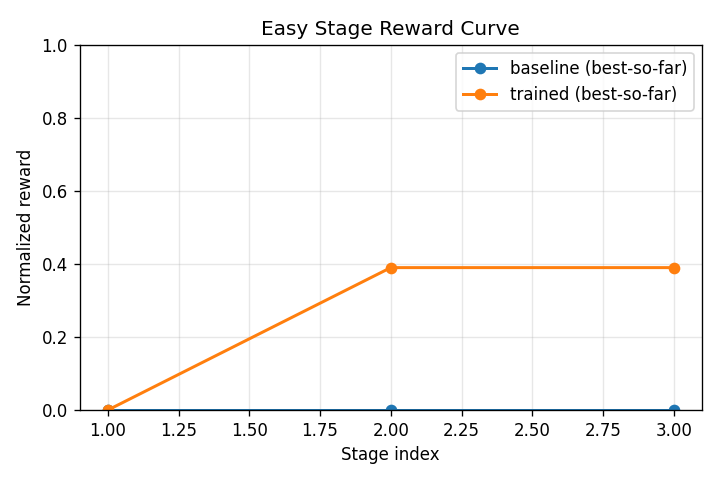

reward_curve_medium.png


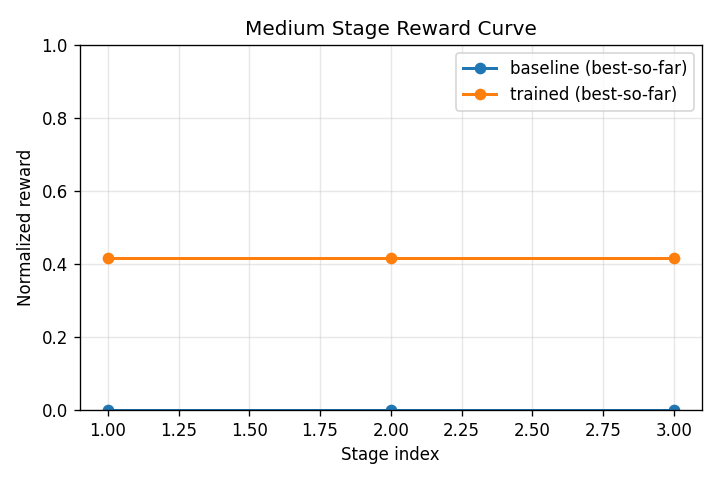

reward_curve_hard.png


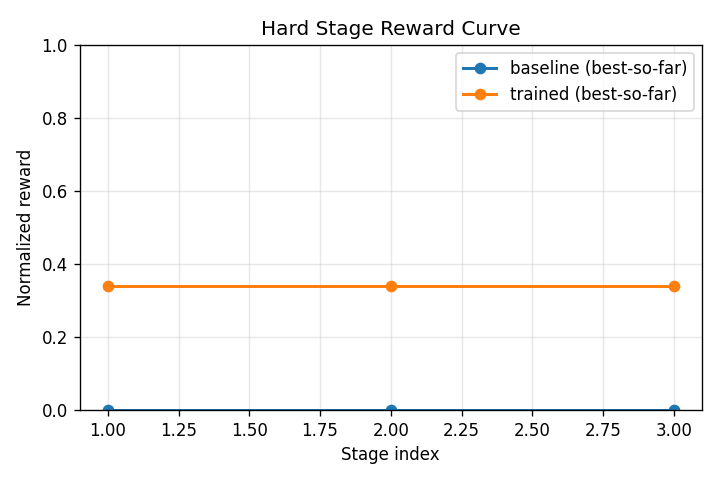

In [16]:
# Step 8: Display mentor graphs (easy/medium/hard)
#
# TRACK = "sandbox" -> VM env  curves from Step 6  (default)
# TRACK = "simple"  -> Mock env curves from the optional Mock-env compare
from pathlib import Path
from IPython.display import Image, display

TRACK = "sandbox"  # change to "simple" only if you uncommented the Mock-env compare
curve_dir = Path("artifacts/eval_simple" if TRACK == "simple" else "artifacts/eval_sandbox")
curves = [
    curve_dir / "reward_curve_easy.png",
    curve_dir / "reward_curve_medium.png",
    curve_dir / "reward_curve_hard.png",
]
missing = [str(p) for p in curves if not p.exists()]
if missing:
    print("Run Step 6 with --plot first. Missing:")
    for p in missing:
        print(" -", p)
else:
    for curve in curves:
        print(curve.name)
        display(Image(filename=str(curve)))
